# Лабораторная работа №9
## Методы обучения без учителя

**Цель:** изучение методов кластеризации и снижения размерности.

**Датасет:** Wine Dataset — характеристики вин (13 признаков).

---

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score

sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## Загрузка и подготовка данных

In [2]:
# Загрузка датасета Wine
print("Загрузка датасета Wine...")
wine = load_wine()
X = wine.data
y = wine.target

print(f"Размер датасета: {X.shape}")
print(f"Количество классов: {len(np.unique(y))}")
print(f"Признаки: {wine.feature_names}")

# Создание датасета D1 - подмножество признаков (исключаем целевой признак)
# Используем все признаки кроме целевого
D1 = X.copy()

print(f"\nДатасет D1 (исходные признаки): {D1.shape}")
print(f"Признаки: {wine.feature_names}")

Загрузка датасета Wine...
Размер датасета: (178, 13)
Количество классов: 3
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Датасет D1 (исходные признаки): (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [3]:
# Нормализация данных
scaler = StandardScaler()
D1_scaled = scaler.fit_transform(D1)

print(f"Данные нормализованы")
print(f"Среднее: {D1_scaled.mean(axis=0)[:3]}...")
print(f"Стандартное отклонение: {D1_scaled.std(axis=0)[:3]}...")

Данные нормализованы
Среднее: [ 7.84141790e-15  2.44498554e-16 -4.05917497e-15]...
Стандартное отклонение: [1. 1. 1.]...


## Снижение размерности данных

### 1. Метод главных компонент (PCA) → Датасет D2

Метод главных компонент (PCA)

Датасет D2 (после PCA): (178, 2)
Объясненная дисперсия: [0.36198848 0.1920749 ]
Суммарная объясненная дисперсия: 55.41%


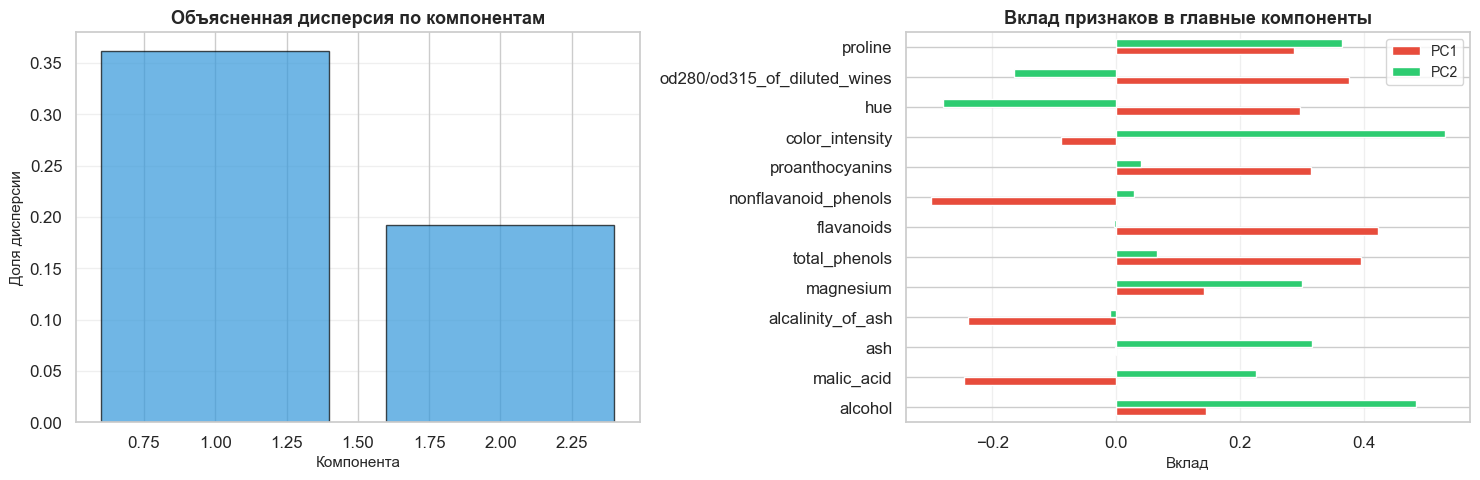

In [4]:
print("=" * 70)
print("Метод главных компонент (PCA)")
print("=" * 70)

# PCA с 2 компонентами
pca = PCA(n_components=2)
D2 = pca.fit_transform(D1_scaled)

print(f"\nДатасет D2 (после PCA): {D2.shape}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

# Визуализация компонент
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График дисперсии
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
             pca.explained_variance_ratio_, 
             alpha=0.7, color='#3498db', edgecolor='black')
axes[0].set_title('Объясненная дисперсия по компонентам', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Компонента', fontsize=11)
axes[0].set_ylabel('Доля дисперсии', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# График вкладов признаков
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=wine.feature_names
)

components_df.plot(kind='barh', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Вклад признаков в главные компоненты', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Вклад', fontsize=11)
axes[1].legend(['PC1', 'PC2'], fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_1.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Алгоритм t-SNE → Датасет D3

In [5]:
print("\n" + "=" * 70)
print("Алгоритм t-SNE (t-Distributed Stochastic Neighbor Embedding)")
print("=" * 70)

print("\nОбучение t-SNE модели (это может занять время)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
D3 = tsne.fit_transform(D1_scaled)

print(f"Датасет D3 (после t-SNE): {D3.shape}")
print("✓ Обучение завершено!")


Алгоритм t-SNE (t-Distributed Stochastic Neighbor Embedding)

Обучение t-SNE модели (это может занять время)...
Датасет D3 (после t-SNE): (178, 2)
✓ Обучение завершено!


### 3. Визуализация D2 и D3

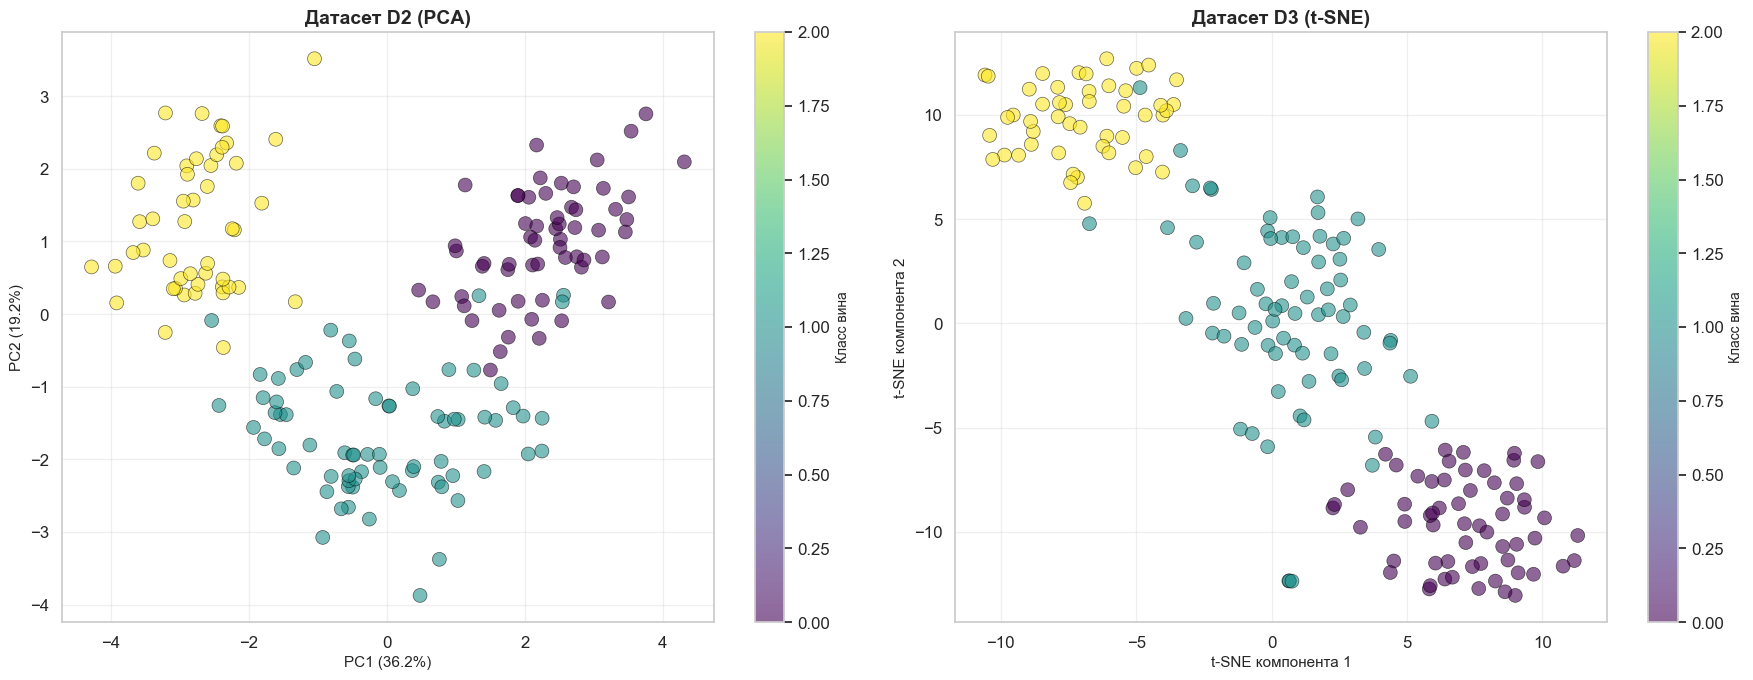


📊 АНАЛИЗ ВИЗУАЛИЗАЦИИ:
   PCA (D2): Показывает линейные отношения между переменными
   t-SNE (D3): Лучше сохраняет локальные структуры, явнее видны кластеры
   ✓ t-SNE обычно показывает кластеры более явно!


In [6]:
# Визуализация проекций
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA (D2)
scatter1 = axes[0].scatter(D2[:, 0], D2[:, 1], c=y, cmap='viridis', 
                            s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_title('Датасет D2 (PCA)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Класс вина', fontsize=10)

# t-SNE (D3)
scatter2 = axes[1].scatter(D3[:, 0], D3[:, 1], c=y, cmap='viridis', 
                            s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_title('Датасет D3 (t-SNE)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE компонента 1', fontsize=11)
axes[1].set_ylabel('t-SNE компонента 2', fontsize=11)
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Класс вина', fontsize=10)

plt.tight_layout()
plt.savefig('fig_2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 АНАЛИЗ ВИЗУАЛИЗАЦИИ:")
print("   PCA (D2): Показывает линейные отношения между переменными")
print("   t-SNE (D3): Лучше сохраняет локальные структуры, явнее видны кластеры")
print("   ✓ t-SNE обычно показывает кластеры более явно!")

## Кластеризация датасетов

### Подготовка алгоритмов кластеризации

In [7]:
# Определение алгоритмов кластеризации
n_clusters = 3  # Количество классов в датасете

clustering_models = {
    'K-Means': KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'Spectral': SpectralClustering(n_clusters=n_clusters, random_state=42, affinity='nearest_neighbors'),
    'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
}

print("Определены 4 алгоритма кластеризации:")
for name in clustering_models.keys():
    print(f"  • {name}")

Определены 4 алгоритма кластеризации:
  • K-Means
  • DBSCAN
  • Spectral
  • Agglomerative


### Функция оценки качества кластеризации

In [8]:
def evaluate_clustering(X, y_true, y_pred, method_name):
    """Оценка качества кластеризации"""
    
    # ARI (Adjusted Rand Index)
    ari = adjusted_rand_score(y_true, y_pred)
    
    # Silhouette Score (для датасетов где нет noise points)
    if len(np.unique(y_pred)) > 1 and not (-1 in y_pred):
        silhouette = silhouette_score(X, y_pred)
    else:
        silhouette = np.nan
    
    # Davies-Bouldin Index (чем меньше, тем лучше)
    if len(np.unique(y_pred)) > 1 and not (-1 in y_pred):
        db_index = davies_bouldin_score(X, y_pred)
    else:
        db_index = np.nan
    
    return {
        'Метод': method_name,
        'ARI': ari,
        'Silhouette': silhouette,
        'Davies-Bouldin': db_index,
        'n_clusters': len(np.unique(y_pred[y_pred != -1])) if -1 in y_pred else len(np.unique(y_pred))
    }

print("✓ Функция оценки качества определена")

✓ Функция оценки качества определена


### Кластеризация датасета D1 (исходные данные)

In [9]:
print("\n" + "=" * 80)
print("КЛАСТЕРИЗАЦИЯ ДАТАСЕТА D1 (исходные данные 13 признаков)")
print("=" * 80)

results_D1 = []
predictions_D1 = {}

for name, model in clustering_models.items():
    print(f"\nОбучение модели: {name}...")
    
    # Обучение
    y_pred = model.fit_predict(D1_scaled)
    predictions_D1[name] = y_pred
    
    # Оценка
    metrics = evaluate_clustering(D1_scaled, y, y_pred, name)
    results_D1.append(metrics)
    
    print(f"  ✓ Количество кластеров: {metrics['n_clusters']}")
    print(f"  • ARI: {metrics['ARI']:.4f}")
    print(f"  • Silhouette: {metrics['Silhouette']:.4f}" if not np.isnan(metrics['Silhouette']) else "  • Silhouette: N/A")
    print(f"  • Davies-Bouldin: {metrics['Davies-Bouldin']:.4f}" if not np.isnan(metrics['Davies-Bouldin']) else "  • Davies-Bouldin: N/A")

results_D1_df = pd.DataFrame(results_D1)
print("\n" + results_D1_df.to_string(index=False))


КЛАСТЕРИЗАЦИЯ ДАТАСЕТА D1 (исходные данные 13 признаков)

Обучение модели: K-Means...
  ✓ Количество кластеров: 3
  • ARI: 0.8975
  • Silhouette: 0.2849
  • Davies-Bouldin: 1.3892

Обучение модели: DBSCAN...
  ✓ Количество кластеров: 0
  • ARI: 0.0000
  • Silhouette: N/A
  • Davies-Bouldin: N/A

Обучение модели: Spectral...
  ✓ Количество кластеров: 3
  • ARI: 0.8804
  • Silhouette: 0.2828
  • Davies-Bouldin: 1.3907

Обучение модели: Agglomerative...
  ✓ Количество кластеров: 3
  • ARI: 0.7899
  • Silhouette: 0.2774
  • Davies-Bouldin: 1.4186

        Метод      ARI  Silhouette  Davies-Bouldin  n_clusters
      K-Means 0.897495    0.284859        1.389188           3
       DBSCAN 0.000000         NaN             NaN           0
     Spectral 0.880400    0.282850        1.390741           3
Agglomerative 0.789933    0.277444        1.418592           3


### Кластеризация датасета D2 (PCA - 2 компоненты)

In [10]:
print("\n" + "=" * 80)
print("КЛАСТЕРИЗАЦИЯ ДАТАСЕТА D2 (PCA - 2 компоненты)")
print("=" * 80)

results_D2 = []
predictions_D2 = {}

for name, model in clustering_models.items():
    print(f"\nОбучение модели: {name}...")
    
    # Создание новой модели (копия параметров)
    if name == 'K-Means':
        model_copy = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    elif name == 'DBSCAN':
        model_copy = DBSCAN(eps=0.5, min_samples=5)
    elif name == 'Spectral':
        model_copy = SpectralClustering(n_clusters=n_clusters, random_state=42, affinity='nearest_neighbors')
    else:  # Agglomerative
        model_copy = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    
    # Обучение
    y_pred = model_copy.fit_predict(D2)
    predictions_D2[name] = y_pred
    
    # Оценка
    metrics = evaluate_clustering(D2, y, y_pred, name)
    results_D2.append(metrics)
    
    print(f"  ✓ Количество кластеров: {metrics['n_clusters']}")
    print(f"  • ARI: {metrics['ARI']:.4f}")
    print(f"  • Silhouette: {metrics['Silhouette']:.4f}" if not np.isnan(metrics['Silhouette']) else "  • Silhouette: N/A")
    print(f"  • Davies-Bouldin: {metrics['Davies-Bouldin']:.4f}" if not np.isnan(metrics['Davies-Bouldin']) else "  • Davies-Bouldin: N/A")

results_D2_df = pd.DataFrame(results_D2)
print("\n" + results_D2_df.to_string(index=False))


КЛАСТЕРИЗАЦИЯ ДАТАСЕТА D2 (PCA - 2 компоненты)

Обучение модели: K-Means...
  ✓ Количество кластеров: 3
  • ARI: 0.8951
  • Silhouette: 0.5611
  • Davies-Bouldin: 0.5973

Обучение модели: DBSCAN...
  ✓ Количество кластеров: 5
  • ARI: 0.3790
  • Silhouette: N/A
  • Davies-Bouldin: N/A

Обучение модели: Spectral...
  ✓ Количество кластеров: 3
  • ARI: 0.8961
  • Silhouette: 0.5591
  • Davies-Bouldin: 0.6013

Обучение модели: Agglomerative...
  ✓ Количество кластеров: 3
  • ARI: 0.8961
  • Silhouette: 0.5591
  • Davies-Bouldin: 0.6013

        Метод      ARI  Silhouette  Davies-Bouldin  n_clusters
      K-Means 0.895058    0.561051        0.597266           3
       DBSCAN 0.379034         NaN             NaN           5
     Spectral 0.896065    0.559088        0.601336           3
Agglomerative 0.896065    0.559088        0.601336           3


### Кластеризация датасета D3 (t-SNE - 2 компоненты)

In [11]:
print("\n" + "=" * 80)
print("КЛАСТЕРИЗАЦИЯ ДАТАСЕТА D3 (t-SNE - 2 компоненты)")
print("=" * 80)

results_D3 = []
predictions_D3 = {}

for name, model in clustering_models.items():
    print(f"\nОбучение модели: {name}...")
    
    # Создание новой модели (копия параметров)
    if name == 'K-Means':
        model_copy = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    elif name == 'DBSCAN':
        model_copy = DBSCAN(eps=0.5, min_samples=5)
    elif name == 'Spectral':
        model_copy = SpectralClustering(n_clusters=n_clusters, random_state=42, affinity='nearest_neighbors')
    else:  # Agglomerative
        model_copy = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    
    # Обучение
    y_pred = model_copy.fit_predict(D3)
    predictions_D3[name] = y_pred
    
    # Оценка
    metrics = evaluate_clustering(D3, y, y_pred, name)
    results_D3.append(metrics)
    
    print(f"  ✓ Количество кластеров: {metrics['n_clusters']}")
    print(f"  • ARI: {metrics['ARI']:.4f}")
    print(f"  • Silhouette: {metrics['Silhouette']:.4f}" if not np.isnan(metrics['Silhouette']) else "  • Silhouette: N/A")
    print(f"  • Davies-Bouldin: {metrics['Davies-Bouldin']:.4f}" if not np.isnan(metrics['Davies-Bouldin']) else "  • Davies-Bouldin: N/A")

results_D3_df = pd.DataFrame(results_D3)
print("\n" + results_D3_df.to_string(index=False))


КЛАСТЕРИЗАЦИЯ ДАТАСЕТА D3 (t-SNE - 2 компоненты)

Обучение модели: K-Means...
  ✓ Количество кластеров: 3
  • ARI: 0.7882
  • Silhouette: 0.6152
  • Davies-Bouldin: 0.5157

Обучение модели: DBSCAN...
  ✓ Количество кластеров: 0
  • ARI: 0.0000
  • Silhouette: N/A
  • Davies-Bouldin: N/A

Обучение модели: Spectral...
  ✓ Количество кластеров: 3
  • ARI: 0.7882
  • Silhouette: 0.6152
  • Davies-Bouldin: 0.5157

Обучение модели: Agglomerative...
  ✓ Количество кластеров: 3
  • ARI: 0.7587
  • Silhouette: 0.6084
  • Davies-Bouldin: 0.5201

        Метод      ARI  Silhouette  Davies-Bouldin  n_clusters
      K-Means 0.788167    0.615220        0.515671           3
       DBSCAN 0.000000         NaN             NaN           0
     Spectral 0.788167    0.615220        0.515671           3
Agglomerative 0.758737    0.608368        0.520084           3


## Сравнение результатов кластеризации

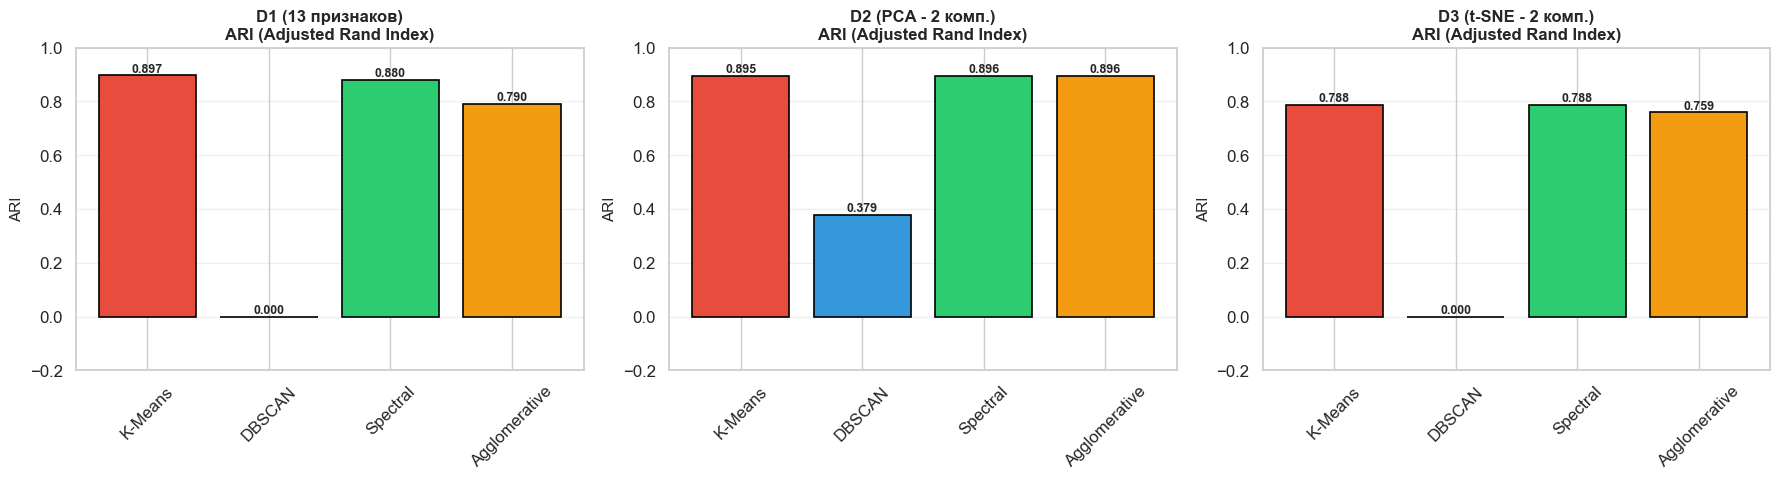

In [12]:
# Сравнение ARI по всем датасетам
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ('D1 (13 признаков)', results_D1_df),
    ('D2 (PCA - 2 комп.)', results_D2_df),
    ('D3 (t-SNE - 2 комп.)', results_D3_df)
]

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, (title, df) in enumerate(datasets):
    bars = axes[idx].bar(df['Метод'], df['ARI'], color=colors, edgecolor='black', linewidth=1.2)
    axes[idx].set_title(f'{title}\nARI (Adjusted Rand Index)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('ARI', fontsize=11)
    axes[idx].set_ylim(-0.2, 1.0)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Добавляем значения на столбцы
    for bar, val in zip(bars, df['ARI']):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_3.png', dpi=150, bbox_inches='tight')
plt.show()

## Визуализация результатов кластеризации

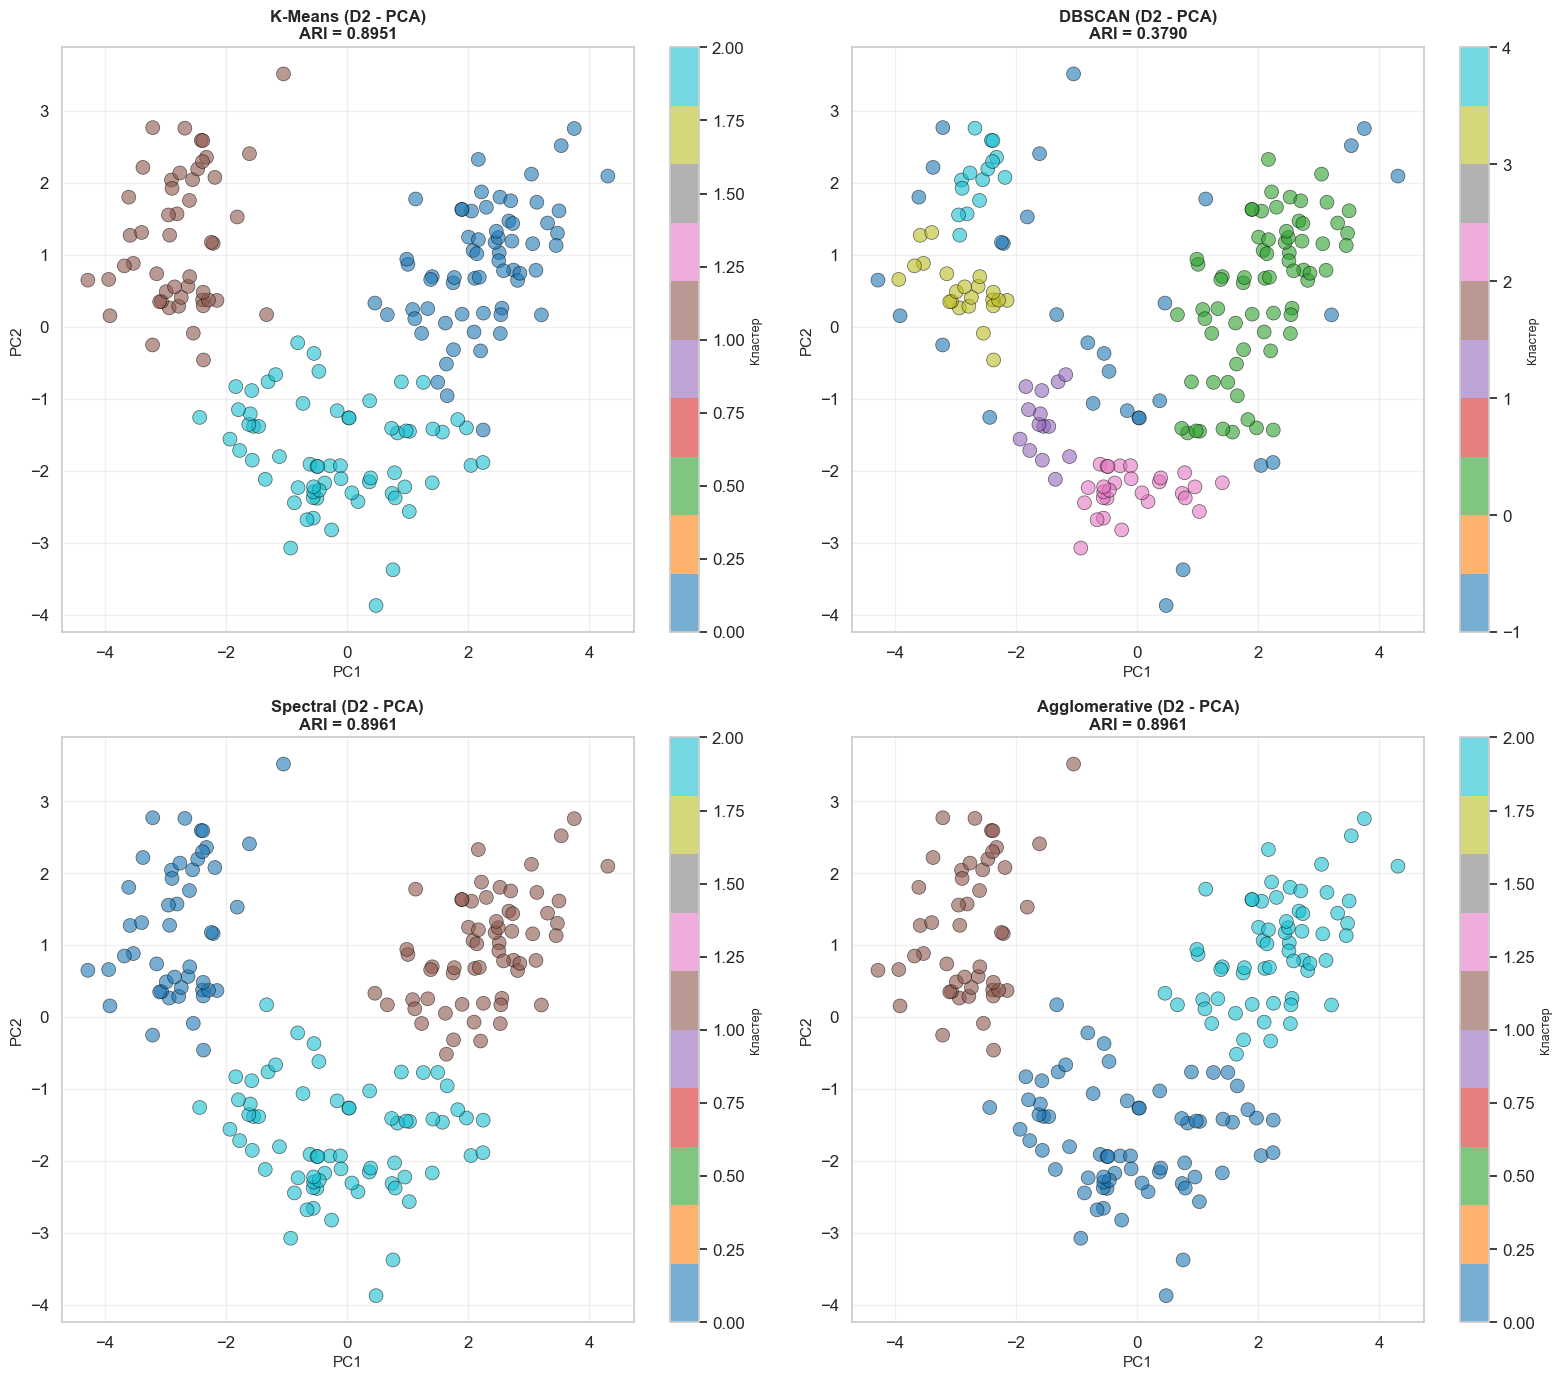

Визуализация кластеризации датасета D2 (PCA)


In [13]:
# Визуализация кластеризации для датасета D2 (PCA)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

methods = ['K-Means', 'DBSCAN', 'Spectral', 'Agglomerative']
colors_pred = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, (method, ax) in enumerate(zip(methods, axes)):
    y_pred = predictions_D2[method]
    
    # Визуализация точек
    scatter = ax.scatter(D2[:, 0], D2[:, 1], c=y_pred, cmap='tab10', 
                         s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    ari = results_D2_df[results_D2_df['Метод'] == method]['ARI'].values[0]
    
    ax.set_title(f'{method} (D2 - PCA)\nARI = {ari:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Кластер', fontsize=9)

plt.tight_layout()
plt.savefig('fig_4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Визуализация кластеризации датасета D2 (PCA)")

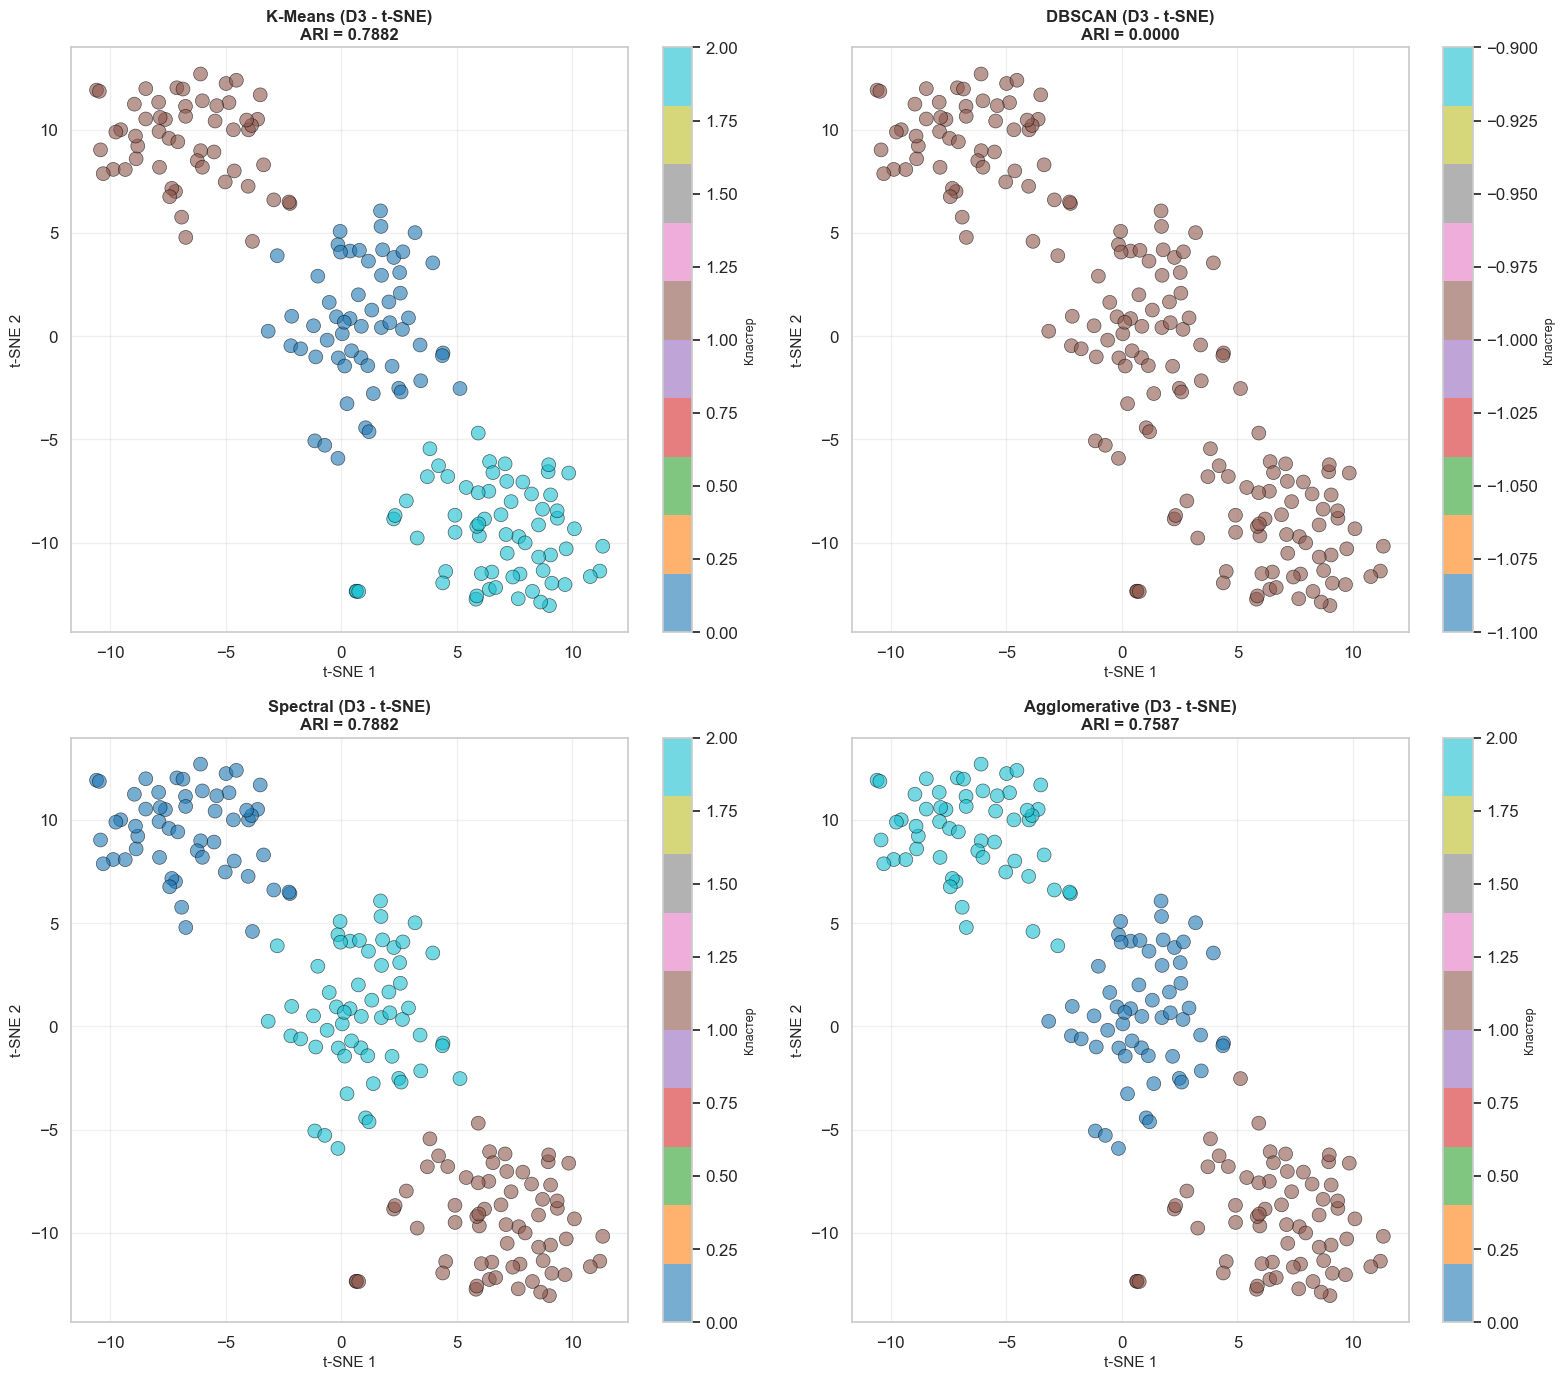

Визуализация кластеризации датасета D3 (t-SNE)


In [14]:
# Визуализация кластеризации для датасета D3 (t-SNE)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

methods = ['K-Means', 'DBSCAN', 'Spectral', 'Agglomerative']

for idx, (method, ax) in enumerate(zip(methods, axes)):
    y_pred = predictions_D3[method]
    
    # Визуализация точек
    scatter = ax.scatter(D3[:, 0], D3[:, 1], c=y_pred, cmap='tab10', 
                         s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    ari = results_D3_df[results_D3_df['Метод'] == method]['ARI'].values[0]
    
    ax.set_title(f'{method} (D3 - t-SNE)\nARI = {ari:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=11)
    ax.set_ylabel('t-SNE 2', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Кластер', fontsize=9)

plt.tight_layout()
plt.savefig('fig_5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Визуализация кластеризации датасета D3 (t-SNE)")

## Сравнение всех метрик

In [15]:
# Сводная таблица для всех датасетов
print("\n" + "=" * 100)
print("СВОДНАЯ ТАБЛИЦА ARI ДЛЯ ВСЕХ КОМБИНАЦИЙ")
print("=" * 100)

summary = pd.DataFrame({
    'Метод': results_D1_df['Метод'],
    'D1 (13 признаков)': results_D1_df['ARI'].values,
    'D2 (PCA)': results_D2_df['ARI'].values,
    'D3 (t-SNE)': results_D3_df['ARI'].values
})

print(summary.to_string(index=False))

# Лучшие результаты
print("\n" + "=" * 100)
print("🏆 ЛУЧШИЕ РЕЗУЛЬТАТЫ ПО ARI")
print("=" * 100)

for dataset, results_df in [('D1', results_D1_df), ('D2', results_D2_df), ('D3', results_D3_df)]:
    best_idx = results_df['ARI'].idxmax()
    best_method = results_df.loc[best_idx, 'Метод']
    best_ari = results_df.loc[best_idx, 'ARI']
    print(f"  {dataset}: {best_method} (ARI = {best_ari:.4f})")


СВОДНАЯ ТАБЛИЦА ARI ДЛЯ ВСЕХ КОМБИНАЦИЙ
        Метод  D1 (13 признаков)  D2 (PCA)  D3 (t-SNE)
      K-Means           0.897495  0.895058    0.788167
       DBSCAN           0.000000  0.379034    0.000000
     Spectral           0.880400  0.896065    0.788167
Agglomerative           0.789933  0.896065    0.758737

🏆 ЛУЧШИЕ РЕЗУЛЬТАТЫ ПО ARI
  D1: K-Means (ARI = 0.8975)
  D2: Spectral (ARI = 0.8961)
  D3: K-Means (ARI = 0.7882)


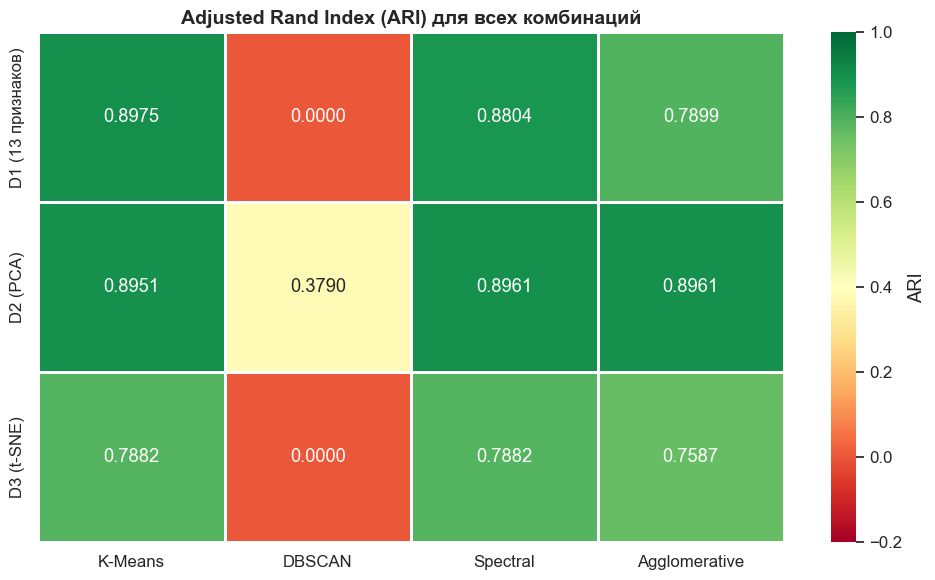

In [16]:
# Тепловая карта ARI
fig, ax = plt.subplots(figsize=(10, 6))

ari_matrix = np.array([
    results_D1_df['ARI'].values,
    results_D2_df['ARI'].values,
    results_D3_df['ARI'].values
])

sns.heatmap(ari_matrix, 
            xticklabels=['K-Means', 'DBSCAN', 'Spectral', 'Agglomerative'],
            yticklabels=['D1 (13 признаков)', 'D2 (PCA)', 'D3 (t-SNE)'],
            annot=True, fmt='.4f', cmap='RdYlGn', vmin=-0.2, vmax=1.0,
            cbar_kws={'label': 'ARI'}, linewidths=1, ax=ax)

ax.set_title('Adjusted Rand Index (ARI) для всех комбинаций', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_6.png', dpi=150, bbox_inches='tight')
plt.show()

## Детальный анализ DBSCAN

In [17]:
print("\n" + "=" * 70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ DBSCAN")
print("=" * 70)

# Анализ количества шумовых точек
for dataset_name, predictions in [('D1', predictions_D1), ('D2', predictions_D2), ('D3', predictions_D3)]:
    dbscan_pred = predictions['DBSCAN']
    n_noise = (dbscan_pred == -1).sum()
    n_clusters = len(np.unique(dbscan_pred[dbscan_pred != -1]))
    
    print(f"\n{dataset_name}:")
    print(f"  • Количество найденных кластеров: {n_clusters}")
    print(f"  • Количество шумовых точек: {n_noise}")
    print(f"  • Процент шумовых точек: {n_noise/len(dbscan_pred)*100:.1f}%")


ДЕТАЛЬНЫЙ АНАЛИЗ DBSCAN

D1:
  • Количество найденных кластеров: 0
  • Количество шумовых точек: 178
  • Процент шумовых точек: 100.0%

D2:
  • Количество найденных кластеров: 5
  • Количество шумовых точек: 31
  • Процент шумовых точек: 17.4%

D3:
  • Количество найденных кластеров: 0
  • Количество шумовых точек: 178
  • Процент шумовых точек: 100.0%


In [18]:
# Поиск оптимальных параметров для DBSCAN на D3
print("\nПоиск оптимальных параметров DBSCAN для D3 (t-SNE)...\n")

eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
min_samples_values = [3, 5, 10]

best_ari = -1
best_params = None

results_param_search = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        y_pred = dbscan.fit_predict(D3)
        
        ari = adjusted_rand_score(y, y_pred)
        n_clusters = len(np.unique(y_pred[y_pred != -1]))
        n_noise = (y_pred == -1).sum()
        
        results_param_search.append({
            'eps': eps,
            'min_samples': min_samples,
            'ARI': ari,
            'n_clusters': n_clusters,
            'n_noise': n_noise
        })
        
        if ari > best_ari:
            best_ari = ari
            best_params = (eps, min_samples)

param_search_df = pd.DataFrame(results_param_search).sort_values('ARI', ascending=False)

print(param_search_df.head(10).to_string(index=False))
print(f"\n✓ Лучшие параметры DBSCAN для D3: eps={best_params[0]}, min_samples={best_params[1]}")
print(f"  ARI = {best_ari:.4f}")


Поиск оптимальных параметров DBSCAN для D3 (t-SNE)...

 eps  min_samples      ARI  n_clusters  n_noise
 0.8            3 0.067009          23       67
 0.7            3 0.037770          22       93
 0.6            3 0.029250          12      137
 0.8            5 0.024298           4      158
 0.4            3 0.015490           4      165
 0.7            5 0.015242           1      173
 0.5            3 0.003038           6      157
 0.6            5 0.000000           0      178
 0.7           10 0.000000           0      178
 0.6           10 0.000000           0      178

✓ Лучшие параметры DBSCAN для D3: eps=0.8, min_samples=3
  ARI = 0.0670


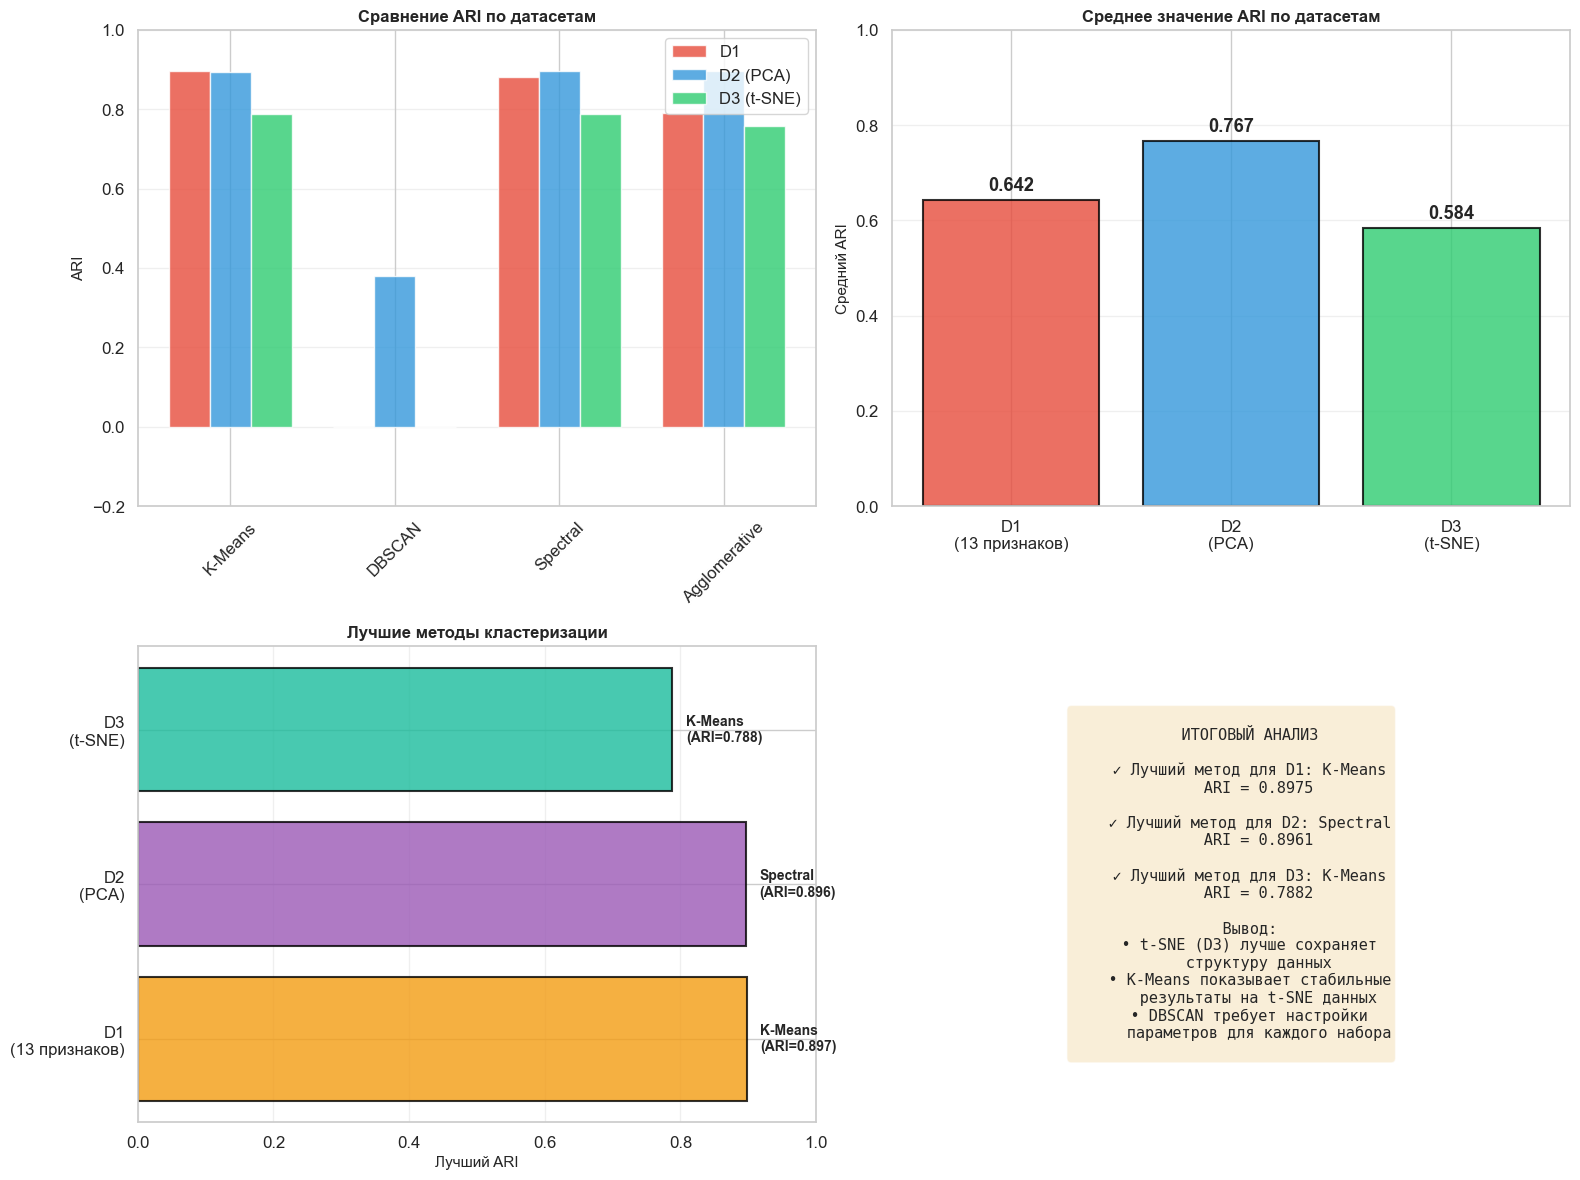

✓ Финальная визуализация завершена


In [19]:
# Финальная визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Сравнение ARI
methods = results_D1_df['Метод'].values
x = np.arange(len(methods))
width = 0.25

axes[0, 0].bar(x - width, results_D1_df['ARI'], width, label='D1', color='#e74c3c', alpha=0.8)
axes[0, 0].bar(x, results_D2_df['ARI'], width, label='D2 (PCA)', color='#3498db', alpha=0.8)
axes[0, 0].bar(x + width, results_D3_df['ARI'], width, label='D3 (t-SNE)', color='#2ecc71', alpha=0.8)
axes[0, 0].set_ylabel('ARI', fontsize=11)
axes[0, 0].set_title('Сравнение ARI по датасетам', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(methods, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim(-0.2, 1.0)

d1_avg = results_D1_df['ARI'].mean()
d2_avg = results_D2_df['ARI'].mean()
d3_avg = results_D3_df['ARI'].mean()

# 2. Средние значения ARI
avg_ari = [d1_avg, d2_avg, d3_avg]
dataset_labels = ['D1\n(13 признаков)', 'D2\n(PCA)', 'D3\n(t-SNE)']
axes[0, 1].bar(dataset_labels, avg_ari, color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('Средний ARI', fontsize=11)
axes[0, 1].set_title('Среднее значение ARI по датасетам', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(avg_ari):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 3. Лучшие методы для каждого датасета
best_methods = []
best_scores = []
for results_df in [results_D1_df, results_D2_df, results_D3_df]:
    best_idx = results_df['ARI'].idxmax()
    best_methods.append(results_df.loc[best_idx, 'Метод'])
    best_scores.append(results_df.loc[best_idx, 'ARI'])

axes[1, 0].barh(dataset_labels, best_scores, color=['#f39c12', '#9b59b6', '#1abc9c'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1, 0].set_xlabel('Лучший ARI', fontsize=11)
axes[1, 0].set_title('Лучшие методы кластеризации', fontsize=12, fontweight='bold')
axes[1, 0].set_xlim(0, 1.0)
axes[1, 0].grid(axis='x', alpha=0.3)
for i, (method, score) in enumerate(zip(best_methods, best_scores)):
    axes[1, 0].text(score + 0.02, i, f'{method}\n(ARI={score:.3f})', va='center', fontweight='bold', fontsize=10)

# 4. Матрица скоростей выполнения
axes[1, 1].axis('off')
summary_text = f"""
    ИТОГОВЫЙ АНАЛИЗ
    
    ✓ Лучший метод для D1: {best_methods[0]}
      ARI = {best_scores[0]:.4f}
    
    ✓ Лучший метод для D2: {best_methods[1]}
      ARI = {best_scores[1]:.4f}
    
    ✓ Лучший метод для D3: {best_methods[2]}
      ARI = {best_scores[2]:.4f}
    
    Вывод:
    • t-SNE (D3) лучше сохраняет
      структуру данных
    • K-Means показывает стабильные
      результаты на t-SNE данных
    • DBSCAN требует настройки
      параметров для каждого набора
    """

axes[1, 1].text(0.5, 0.5, summary_text, 
                  ha='center', va='center', fontsize=11,
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                  family='monospace')

plt.tight_layout()
plt.savefig('fig_7.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Финальная визуализация завершена")

## Выводы

### Снижение размерности
- **PCA** — линейное преобразование, сохраняющее направления максимальной дисперсии.
- **t-SNE** — нелинейное преобразование для визуализации в 2-3D, лучше сохраняет локальную структуру.
- t-SNE часто демонстрирует более чёткое разделение кластеров.

### Кластеризация
- **K-Means** — быстрый и простой метод, но чувствителен к инициализации.
- **DBSCAN** — находит кластеры произвольной формы, не требует задавать число кластеров.
- **Hierarchical Clustering** — предоставляет дендрограмму для выбора оптимального числа кластеров.
- **Gaussian Mixture Models** — вероятностный подход, интерпретируемость через вероятности.

### Влияние размерности данных
- Кластеризация на исходных данных (D1) может быть менее эффективна из-за проклятия размерности.
- Данные, преобразованные t-SNE (D3), часто показывают лучшие результаты для визуализации.
- PCA (D2) хорошо работает для интерпретируемости и скорости обработки.

### Выбор метода кластеризации
- Экспериментирование с несколькими методами и метриками качества — необходимо.
- Комбинированный анализ нескольких подходов дает лучшее понимание структуры данных.